# CSCI 218 Group Assignment - FER

## Download and Extract RAF-DB Dataset from Kaggle

In [34]:
import os

DATASET_DIR = "RAF-DB"

if not os.path.exists(DATASET_DIR):
    print("DATASET folder not found. Downloading from Kaggle...")

    # Install Kaggle API
    !pip install -q kaggle

    # Upload kaggle.json
    from google.colab import files
    print("Please upload your kaggle.json file:")
    uploaded = files.upload()

    # Setup Kaggle credentials
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download RAF-DB dataset
    print("\nDownloading RAF-DB dataset from Kaggle...")
    !kaggle datasets download -d shuvoalok/raf-db-dataset

    # Unzip dataset
    print("\nExtracting dataset...")
    !unzip -q raf-db-dataset.zip -d {DATASET_DIR}

    print("✅ Dataset downloaded and extracted successfully!\n")
else:
    print("✅ DATASET folder already exists. Skipping download.\n")


✅ DATASET folder already exists. Skipping download.



## Environment Setup

In [35]:
# Core Libraries
import os
import random
from collections import Counter, defaultdict
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

# PyTorch & Torchvision
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, WeightedRandomSampler, Subset
from torchvision import datasets, transforms, models

# scikit-learn & visualization libraries
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

## Hyperparameter Configuration

In [36]:
# Random seed for reproducibility
SEED = 42

# Training parameters
BATCH_SIZE = 64
EPOCHS = 40
WARMUP_EPOCHS = 12
LR = 0.001
FINETUNE_LR = 0.0001
WEIGHT_DECAY = 1e-4

# Dataset paths
TRAIN_DIR = '/content/RAF-DB/DATASET/train'
TEST_DIR = '/content/RAF-DB/DATASET/test'

# Data augmentation toggles
USE_MIXUP = True
USE_CUTMIX = True
USE_MIXUP_CUTMIX = True
MIXUP_CUTMIX_PROB = 0.5

# Label smoothing
LABEL_SMOOTHING = 0.1

# MixUp / CutMix parameters
MIXUP_ALPHA = 0.4
CUTMIX_ALPHA = 1.0

# Early stopping
MAX_PATIENCE = 5

# Val split
VAL_SPLIT=0.15

# Class label
EMOTION_LABELS = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']

## Reproducibility Configuration

In [37]:
# Set random seeds for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

# Select device for training
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Data Augmentation Pipeline

In [38]:
# Geometric Augmentations
HFLIP_PROB = 0.5
ROTATION_DEGREES = 5
AFFINE_TRANSLATE = (0.03, 0.03)
AFFINE_SCALE = (0.97, 1.03)

# Color Augmentations
COLOR_JITTER = (0.1, 0.1, 0.1, 0.02)
# (Disabled)
GRAYSCALE_PROB = 0.0

# Noise/Blur (Disabled)
GAUSSIAN_BLUR_PROB = 0.0
GAUSSIAN_BLUR_KERNEL = 3

# Random Erasing (Disabled)
RANDOM_ERASING_PROB = 0.0
RANDOM_ERASING_SCALE = (0.02, 0.15)

In [39]:
# Training data transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Random geometric transformations
    transforms.RandomHorizontalFlip(p=HFLIP_PROB),
    transforms.RandomRotation(degrees=ROTATION_DEGREES),
    transforms.RandomAffine(degrees=0, translate=AFFINE_TRANSLATE, scale=AFFINE_SCALE),

    # Random color adjustments
    transforms.ColorJitter(*COLOR_JITTER),
    transforms.RandomGrayscale(p=GRAYSCALE_PROB),

    # Random blur
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=GAUSSIAN_BLUR_KERNEL)], p=GAUSSIAN_BLUR_PROB),

    # Convert to tensor and normalize
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),

    # Random erasing for regularization
    transforms.RandomErasing(p=RANDOM_ERASING_PROB, scale=RANDOM_ERASING_SCALE)
])

# Test/validation data transformations
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Advanced Augmentation: MixUp & CutMix

In [40]:
class MixUpCutMix:
    def __init__(self, mixup_alpha=MIXUP_ALPHA, cutmix_alpha=CUTMIX_ALPHA,
                 use_mixup=True, use_cutmix=True, num_classes=0):
        # Store parameters
        self.mixup_alpha = mixup_alpha
        self.cutmix_alpha = cutmix_alpha
        self.use_mixup = use_mixup
        self.use_cutmix = use_cutmix
        self.num_classes = num_classes

        # Determine available augmentation modes
        self.modes = []
        if use_mixup:
            self.modes.append('mixup')
        if use_cutmix:
            self.modes.append('cutmix')

        # Ensure at least one mode is enabled
        if not self.modes:
            raise ValueError("At least one of use_mixup or use_cutmix must be True")

    def __call__(self, batch):
        images, labels = batch
        batch_size = images.size(0)

        # Randomly choose augmentation mode
        mode = random.choice(self.modes)

        if mode == 'mixup':
            return self.mixup(images, labels, batch_size)
        else:
            return self.cutmix(images, labels, batch_size)

    def mixup(self, images, labels, batch_size):
        # MixUp: linear interpolation of images and labels
        lam = np.random.beta(self.mixup_alpha, self.mixup_alpha)
        indices = torch.randperm(batch_size).to(images.device)

        mixed_images = lam * images + (1 - lam) * images[indices]

        # Convert labels to one-hot and mix
        labels_a = torch.nn.functional.one_hot(labels, num_classes=self.num_classes).float()
        labels_b = torch.nn.functional.one_hot(labels[indices], num_classes=self.num_classes).float()
        mixed_labels = lam * labels_a + (1 - lam) * labels_b

        return mixed_images, mixed_labels, lam, indices, 'mixup'

    def cutmix(self, images, labels, batch_size):
        # CutMix: cut and paste patches between images
        lam = np.random.beta(self.cutmix_alpha, self.cutmix_alpha)
        indices = torch.randperm(batch_size).to(images.device)

        # Random box coordinates
        _, _, h, w = images.shape
        cut_ratio = np.sqrt(1. - lam)
        cut_h = int(h * cut_ratio)
        cut_w = int(w * cut_ratio)
        cx = np.random.randint(h)
        cy = np.random.randint(w)

        x1 = np.clip(cx - cut_w // 2, 0, w)
        y1 = np.clip(cy - cut_h // 2, 0, h)
        x2 = np.clip(cx + cut_w // 2, 0, w)
        y2 = np.clip(cy + cut_h // 2, 0, h)

        # Apply CutMix to images
        mixed_images = images.clone()
        mixed_images[:, :, y1:y2, x1:x2] = images[indices, :, y1:y2, x1:x2]

        # Adjust lambda based on actual area
        lam = 1 - ((x2 - x1) * (y2 - y1) / (w * h))

        # Convert labels to one-hot and mix
        labels_a = torch.nn.functional.one_hot(labels, num_classes=self.num_classes).float()
        labels_b = torch.nn.functional.one_hot(labels[indices], num_classes=self.num_classes).float()
        mixed_labels = lam * labels_a + (1 - lam) * labels_b

        return mixed_images, mixed_labels, lam, indices, 'cutmix'

## Dataset Preparation & Sampling

In [41]:
# Load full training dataset
full_train = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)

# Get emotion classes and number of classes
EMOTIONS = full_train.classes
num_classes = len(EMOTIONS)

# Split dataset into training and validation
total_len = len(full_train)
val_len = int(VAL_SPLIT * total_len)
train_len = total_len - val_len
train_indices, val_indices = random_split(range(total_len), [train_len, val_len],
                                          generator=torch.Generator().manual_seed(SEED))

# Create separate datasets
val_full = datasets.ImageFolder(TRAIN_DIR, transform=test_transform)
train_ds = Subset(full_train, train_indices)
val_ds = Subset(val_full, val_indices)

# Load test dataset
test_ds = datasets.ImageFolder(TEST_DIR, transform=test_transform)

# Print dataset sizes
print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

# Compute weighted sampler for imbalanced dataset
train_labels = [full_train.targets[i] for i in train_ds.indices]
class_counts = Counter(train_labels)
weights = [len(train_labels) / (num_classes * class_counts[l]) for l in train_labels]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

# Create data loaders
train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Initialize MixUp/CutMix if enabled
mixup_cutmix = None
if USE_MIXUP_CUTMIX and (USE_MIXUP or USE_CUTMIX):
    mixup_cutmix = MixUpCutMix(
        mixup_alpha=MIXUP_ALPHA,
        cutmix_alpha=CUTMIX_ALPHA,
        use_mixup=USE_MIXUP,
        use_cutmix=USE_CUTMIX,
        num_classes=num_classes
    )
    print(f"✅ MixUp/CutMix enabled: MixUp={USE_MIXUP}, CutMix={USE_CUTMIX}")
else:
    print("❌ MixUp/CutMix disabled")

Train: 10431, Val: 1840, Test: 3068
✅ MixUp/CutMix enabled: MixUp=True, CutMix=True


## Model Architecture

In [42]:
# Initialize ResNet18 for classification
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

## Optimization Configuration

In [43]:
# Loss and optimizer
class_weights = torch.tensor([len(train_labels)/(num_classes*class_counts[i]) for i in range(num_classes)]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Learning rate schedulers
scheduler_warmup = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=WARMUP_EPOCHS, eta_min=FINETUNE_LR)
scheduler_plateau = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

## Training & Evaluation Functions

In [44]:
# Training for one epoch with optional MixUp/CutMix
def train_epoch(model, loader, criterion, optimizer, device,
                mixup_cutmix=None, use_mixup=True, epoch=0):

    model.train()
    running_loss = 0.0
    correct = 0.0
    total = 0

    mixup_count = 0
    cutmix_count = 0
    normal_count = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1} [Train]", leave=False)

    for batch_idx, (x, y) in enumerate(pbar):
        x, y = x.to(device), y.to(device)
        batch_size = x.size(0)

        use_augmentation = (
            use_mixup and
            mixup_cutmix is not None and
            random.random() < MIXUP_CUTMIX_PROB
        )

        if use_augmentation:
            x, y_mixed, lam, indices, aug_type = mixup_cutmix((x, y))
            outputs = model(x)

            # Soft target cross entropy (MixUp / CutMix)
            loss_train = -(y_mixed * torch.log_softmax(outputs, dim=1)).sum(dim=1).mean()

            if aug_type == 'mixup':
                mixup_count += 1
            else:
                cutmix_count += 1

            # Weighted accuracy (correct implementation)
            _, predicted = outputs.max(1)
            correct += (
                lam * predicted.eq(y).sum().item() +
                (1 - lam) * predicted.eq(y[indices]).sum().item()
            )

            aug_status = f"{aug_type}({lam:.2f})"

        else:
            normal_count += 1
            outputs = model(x)
            loss_train = criterion(outputs, y)

            _, predicted = outputs.max(1)
            correct += predicted.eq(y).sum().item()

            aug_status = "normal"

        # Backpropagation
        optimizer.zero_grad()
        loss_train.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Accumulate REAL training loss
        running_loss += loss_train.item() * batch_size
        total += batch_size

        pbar.set_postfix({
            'loss': f'{loss_train.item():.4f}',
            'acc': f'{100. * correct / total:.2f}%',
            'type': aug_status
        })

    pbar.close()

    total_batches = mixup_count + cutmix_count + normal_count
    if total_batches > 0:
        print(f"  Augmentations - MixUp: {mixup_count} ({100*mixup_count/total_batches:.1f}%), "
              f"CutMix: {cutmix_count} ({100*cutmix_count/total_batches:.1f}%), "
              f"Normal: {normal_count} ({100*normal_count/total_batches:.1f}%)")

    return running_loss / total, 100. * correct / total

In [45]:
# Evaluate model on validation or test set
@torch.no_grad()
def evaluate(model, loader, criterion, device, desc="Val"):
    model.eval()
    running_loss = correct = total = 0

    val_criterion = nn.CrossEntropyLoss()

    # Batch-wise progress bar
    pbar = tqdm(loader, desc=f"[{desc}]", leave=False)

    for x, y in pbar:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = val_criterion(outputs, y)
        running_loss += loss.item() * x.size(0)
        correct += outputs.argmax(1).eq(y).sum().item()
        total += y.size(0)

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })

    pbar.close()
    return running_loss / total, 100 * correct / total

## Model Training

In [46]:
# Initialize best accuracy and early stopping counter
best_acc = 0
patience_counter = 0

# History dictionary to store metrics
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

print("\nStarting training...")
print("=" * 60)

# Start total training timer
total_start_time = time.time()

# Main training loop
for epoch in range(EPOCHS):
    epoch_start_time = time.time()  # start timer for this epoch

    current_lr = optimizer.param_groups[0]['lr']
    print(f"\nEpoch {epoch+1}/{EPOCHS} | LR: {current_lr:.6f}")

    # Enable MixUp/CutMix for early epochs
    use_mixup = USE_MIXUP_CUTMIX

    # Train for one epoch
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, device,
        mixup_cutmix=mixup_cutmix, use_mixup=use_mixup, epoch=epoch
    )

    # Evaluate on validation set
    val_loss, val_acc = evaluate(model, val_loader, criterion, device, desc="Val")

    # Update learning rate
    if epoch < WARMUP_EPOCHS:
        scheduler_warmup.step()
    else:
        if epoch == WARMUP_EPOCHS:
            optimizer.param_groups[0]['lr'] = FINETUNE_LR
            print(f"🚨 Switched to finetune LR: {FINETUNE_LR}")
        scheduler_plateau.step(val_acc)

    # Record metrics
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(optimizer.param_groups[0]['lr'])

    # Epoch time
    epoch_time = time.time() - epoch_start_time

    # Print epoch summary
    mixup_status = "ON" if use_mixup else "OFF"
    print(f"Train: {train_loss:.4f} / {train_acc:.2f}% | "
          f"Val: {val_loss:.4f} / {val_acc:.2f}% | MixUp: {mixup_status} | "
          f"Epoch Time: {epoch_time:.1f}s")

    # Save best model and reset patience
    if val_acc > best_acc:
        best_acc = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
            'classes': EMOTIONS,
            'seed': SEED,
            'config': {
                'use_mixup': USE_MIXUP,
                'use_cutmix': USE_CUTMIX,
                'label_smoothing': LABEL_SMOOTHING
            }
        }, 'best_model.pt')
        print(f"✅ Saved best model: {val_acc:.2f}%")
    else:
        # Increment patience for early stopping
        patience_counter += 1
        print(f"\n⚠️ No improvement ({patience_counter}/{MAX_PATIENCE})")
        if patience_counter >= MAX_PATIENCE:
            print(f"🛑 Early stopping at epoch {epoch+1}")
            break

# Total training time
total_time = time.time() - total_start_time
print(f"\nBest Val Acc: {best_acc:.2f}%")
print(f"Total Training Time: {total_time/60:.2f} min ({total_time:.1f}s)")


Starting training...

Epoch 1/40 | LR: 0.001000


  Augmentations - MixUp: 39 (23.9%), CutMix: 38 (23.3%), Normal: 86 (52.8%)


Train: 1.5115 / 40.76% | Val: 1.3016 / 47.45% | MixUp: ON | Epoch Time: 75.3s
✅ Saved best model: 47.45%

Epoch 2/40 | LR: 0.000985


  Augmentations - MixUp: 40 (24.5%), CutMix: 37 (22.7%), Normal: 86 (52.8%)


Train: 1.2676 / 53.13% | Val: 1.7803 / 33.48% | MixUp: ON | Epoch Time: 76.3s

⚠️ No improvement (1/5)

Epoch 3/40 | LR: 0.000940


...

Train: 0.6966 / 84.09% | Val: 0.6118 / 83.91% | MixUp: ON | Epoch Time: 74.9s

⚠️ No improvement (3/5)

Epoch 27/40 | LR: 0.000050


  Augmentations - MixUp: 33 (20.2%), CutMix: 42 (25.8%), Normal: 88 (54.0%)


Train: 0.6255 / 87.41% | Val: 0.5616 / 83.48% | MixUp: ON | Epoch Time: 74.9s

⚠️ No improvement (4/5)

Epoch 28/40 | LR: 0.000025


  Augmentations - MixUp: 31 (19.0%), CutMix: 41 (25.2%), Normal: 91 (55.8%)


Train: 0.6190 / 88.27% | Val: 0.5943 / 84.29% | MixUp: ON | Epoch Time: 74.3s

⚠️ No improvement (5/5)
🛑 Early stopping at epoch 28

Best Val Acc: 84.35%
Total Training Time: 34.91 min (2094.4s)


## Results Analysis & Visualization


Test Accuracy: 84.75%
Average Inference Time per Batch: 47.87 ms

Classification Report:
              precision    recall  f1-score   support

    Surprise     0.8256    0.8632    0.8440       329
        Fear     0.6615    0.5811    0.6187        74
     Disgust     0.5878    0.5437    0.5649       160
   Happiness     0.9583    0.8911    0.9235      1185
     Sadness     0.8476    0.8264    0.8369       478
       Anger     0.7432    0.8395    0.7884       162
     Neutral     0.7882    0.8809    0.8319       680

    accuracy                         0.8475      3068
   macro avg     0.7732    0.7751    0.7726      3068
weighted avg     0.8513    0.8475    0.8480      3068



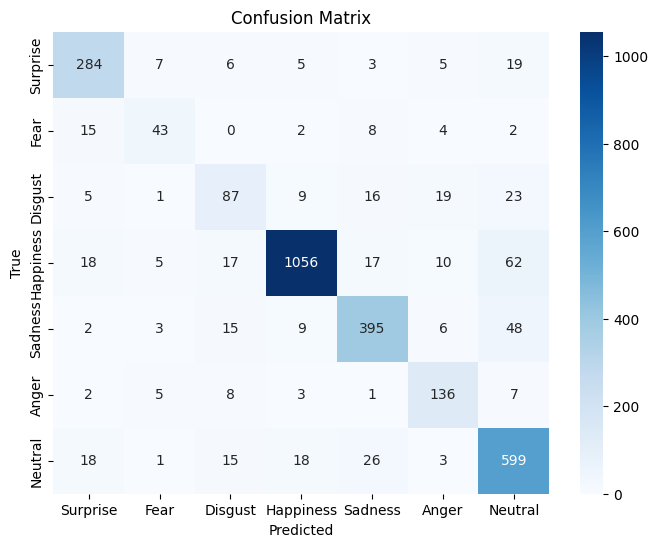

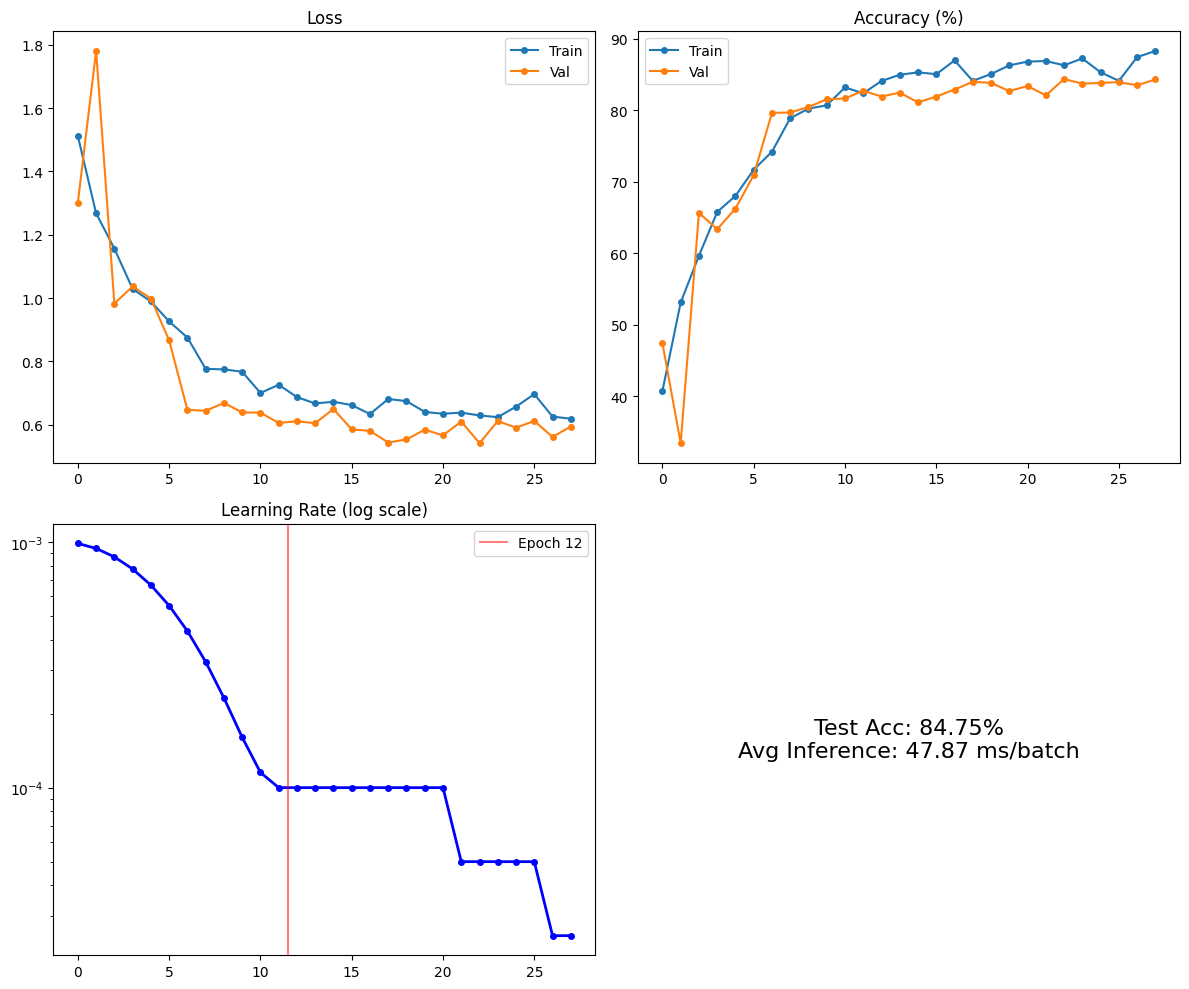

In [47]:
# Load best model
checkpoint = torch.load('best_model.pt', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# Evaluation on test set
all_preds = []
all_labels = []

# Track per-class correct for accuracy
class_correct = defaultdict(int)
class_total = defaultdict(int)

# Timing
inference_times = []

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)

        # Measure time per batch
        start_time = time.time()
        outputs = model(x)
        if device.type == 'cuda':
            torch.cuda.synchronize()  # wait for GPU
        end_time = time.time()
        inference_times.append(end_time - start_time)

        # Predictions
        preds = outputs.argmax(1)

        # Collect all predictions / labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

        # Per-class counts
        for label, pred in zip(y, preds):
            class_total[label.item()] += 1
            if label == pred:
                class_correct[label.item()] += 1

# Compute test metrics
total_correct = sum(class_correct.values())
total_samples = sum(class_total.values())
test_acc = 100.0 * total_correct / total_samples
avg_inference_time_ms = np.mean(inference_times) * 1000  # ms per batch

print(f"\nTest Accuracy: {test_acc:.2f}%")
print(f"Average Inference Time per Batch: {avg_inference_time_ms:.2f} ms")

# Classification report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=EMOTION_LABELS, digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Training metrics plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Loss
axes[0,0].plot(history['train_loss'], label='Train', marker='o', markersize=4, linestyle='-')
axes[0,0].plot(history['val_loss'], label='Val', marker='o', markersize=4, linestyle='-')
axes[0,0].set_title('Loss')
axes[0,0].legend()

# Accuracy
axes[0,1].plot(history['train_acc'], label='Train', marker='o', markersize=4, linestyle='-')
axes[0,1].plot(history['val_acc'], label='Val', marker='o', markersize=4, linestyle='-')
axes[0,1].set_title('Accuracy (%)')
axes[0,1].legend()

# Learning rate
axes[1,0].plot(history['lr'], marker='o', markersize=4, linestyle='-', color='b', linewidth=2)
axes[1,0].axvline(x=WARMUP_EPOCHS-0.5, color='r', linestyle='-', alpha=0.5,
                  label=f'Epoch {WARMUP_EPOCHS}')
axes[1,0].set_title('Learning Rate (log scale)')
axes[1,0].set_yscale('log')
axes[1,0].legend()

# Test accuracy + inference time
axes[1,1].text(
    0.5, 0.5,
    f'Test Acc: {test_acc:.2f}%\nAvg Inference: {avg_inference_time_ms:.2f} ms/batch',
    ha='center', va='center', fontsize=16
)
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

### Export Model to ONNX Format

In [50]:
!pip install onnx onnxruntime onnxscript -q
import onnx
import warnings
import sys
import logging

warnings.filterwarnings("ignore")
logging.disable(logging.WARNING)

# Export with opset 18
model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    "fer_resnet18.onnx",
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}
)

# Verify
onnx_model = onnx.load("fer_resnet18.onnx")
onnx.checker.check_model(onnx_model)
print("✅ Model exported and validated")

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 40 of general pattern rewrite rules.
✅ Model exported and validated
